In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

## Building an Image Classifier
### Install and import TensorFlow and Keras

```
conda create -n tf_env python=3.10 # Uses python 3.10
conda install tensorflow
conda install pip
pip install --upgrade tensorflow==2.0.0-rc1
```

In [2]:
import tensorflow as tf
from tensorflow import keras

2026-04-24 22:03:23.332680: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
keras.__version__

'3.6.0'

In [4]:
tf.__version__

'2.18.1'

In [5]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

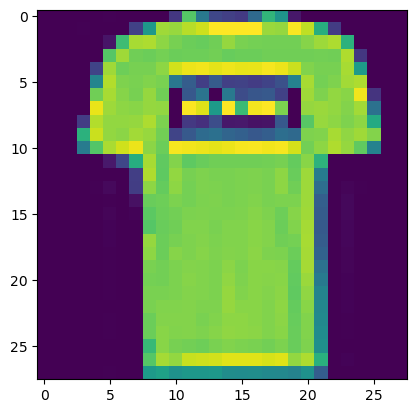

In [6]:
plt.imshow(X_train_full[1])

In [7]:
y_train_full[1]

np.uint8(0)

In [8]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [9]:
class_names[y_train_full[1]]

'T-shirt/top'

In [10]:
X_train_full[1]

array([[  0,   0,   0,   0,   0,   1,   0,   0,   0,   0,  41, 188, 103,
         54,  48,  43,  87, 168, 133,  16,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0,   0,  49, 136, 219, 216, 228, 236,
        255, 255, 255, 255, 217, 215, 254, 231, 160,  45,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  14, 176, 222, 224, 212, 203, 198, 196,
        200, 215, 204, 202, 201, 201, 201, 209, 218, 224, 164,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 188, 219, 200, 198, 202, 198, 199, 199,
        201, 196, 198, 198, 200, 200, 200, 200, 201, 200, 225,  41,   0,
          0,   0],
       [  0,   0,   0,   0,  51, 219, 199, 203, 203, 212, 238, 248, 250,
        245, 249, 246, 247, 252, 248, 235, 207, 203, 203, 222, 140,   0,
          0,   0],
       [  0,   0,   0,   0, 116, 226, 206, 204, 207, 204, 101,  75,  47,
         73,  48,  50,  45,  51,  63, 113, 222, 202, 206, 220, 224,   0,
          0,   0],
       [  

### Data Normalization
We then normilize the data dimensions so that they're of approx the same scale

In [11]:
X_train_n = X_train_full / 255.0 # Because the pixel values are between 0 and 255, we can divide by 255 to get values between 0 and 1
X_test_n = X_test / 255.0 # Normalize the test set as well

## Test-Train Split
### Split the data into train/validation/test datasets
- Training data - used for training the model
- Validation data - used for tuning the hyperparameters of the model
- Test data - used for evaluating the model after training and tuning

In [12]:
X_valid, X_train = X_train_n[:5000], X_train_n[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test_n

In [13]:
X_valid[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

## Different Ways to create mode ANN in Keras
- Sequential model API
- Functional API
- Subclassing API

In [14]:
np.random.seed(42)
tf.random.set_seed(42)

In [15]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28])) # Input layer that flattens the 28x28 images into a 1D array of 784 pixels
model.add(keras.layers.Dense(300, activation="relu")) # Hidden layer with 300 neurons and ReLU activation
model.add(keras.layers.Dense(100, activation="relu")) # Hidden layer with 100 neurons and ReLU activation
model.add(keras.layers.Dense(10, activation="softmax")) # Output layer with 10 neurons and softmax activation

/opt/miniconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

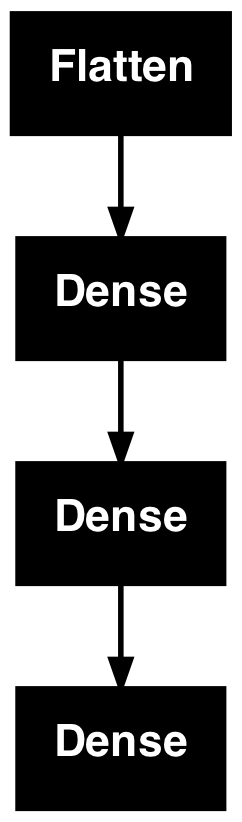

In [17]:
import pydot
keras.utils.plot_model(model)

We can access the parameters using the get_weight() method. It returns a list containing the weights and the biases:

In [18]:
weights, biases = model.layers[1].get_weights()

In [19]:
weights

array([[ 0.06499928,  0.01500382, -0.03198495, ...,  0.02412487,
         0.01708111,  0.06821957],
       [ 0.0165631 , -0.04461874,  0.04747351, ...,  0.03071118,
        -0.04953198,  0.0453241 ],
       [ 0.05693838, -0.06593128, -0.06191332, ..., -0.02223094,
        -0.0253666 ,  0.02115002],
       ...,
       [ 0.0162191 , -0.0297387 , -0.07144919, ...,  0.06307058,
         0.02816312,  0.05025753],
       [-0.06023951, -0.07191249,  0.04725221, ...,  0.04303977,
         0.03336682,  0.01152613],
       [ 0.02746712,  0.06019415, -0.05823398, ...,  0.0065674 ,
         0.05426529, -0.02274223]], dtype=float32)

In [20]:
weights.shape

(784, 300)

In [21]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [22]:
biases.shape

(300,)

In [23]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [24]:
model_history = model.fit(X_train, y_train, epochs=30,
                          validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.6901 - loss: 0.9971 - val_accuracy: 0.8194 - val_loss: 0.5262
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8251 - loss: 0.5017 - val_accuracy: 0.8452 - val_loss: 0.4580
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8430 - loss: 0.4489 - val_accuracy: 0.8554 - val_loss: 0.4245
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8522 - loss: 0.4195 - val_accuracy: 0.8618 - val_loss: 0.4028
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8586 - loss: 0.3983 - val_accuracy: 0.8670 - val_loss: 0.3875
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8649 - loss: 0.3815 - val_accuracy: 0.8686 - val_loss: 0.3748
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8693 - loss: 0.3674 - val_accuracy: 0.8700 - val_loss: 0.3654
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8734 - loss: 0.35

In [25]:
model_history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [26]:
model_history.history

{'accuracy': [0.765890896320343,
  0.8303818106651306,
  0.8452181816101074,
  0.8543272614479065,
  0.8607636094093323,
  0.8664000034332275,
  0.8707636594772339,
  0.8744909167289734,
  0.8782545328140259,
  0.8811636567115784,
  0.8836545348167419,
  0.8862000107765198,
  0.8886727094650269,
  0.890927255153656,
  0.8930181860923767,
  0.8952363729476929,
  0.8973090648651123,
  0.8992363810539246,
  0.9014727473258972,
  0.9030545353889465,
  0.9046909213066101,
  0.9069272875785828,
  0.9085454344749451,
  0.9107636213302612,
  0.9126726984977722,
  0.9141454696655273,
  0.9151999950408936,
  0.9169999957084656,
  0.9182000160217285,
  0.9197272658348083],
 'loss': [0.7210378646850586,
  0.48733457922935486,
  0.44259610772132874,
  0.4155474007129669,
  0.3955203592777252,
  0.3793926239013672,
  0.36562883853912354,
  0.35355842113494873,
  0.34301814436912537,
  0.3335733413696289,
  0.3249128758907318,
  0.3169645667076111,
  0.3095766007900238,
  0.30265992879867554,
  0.296

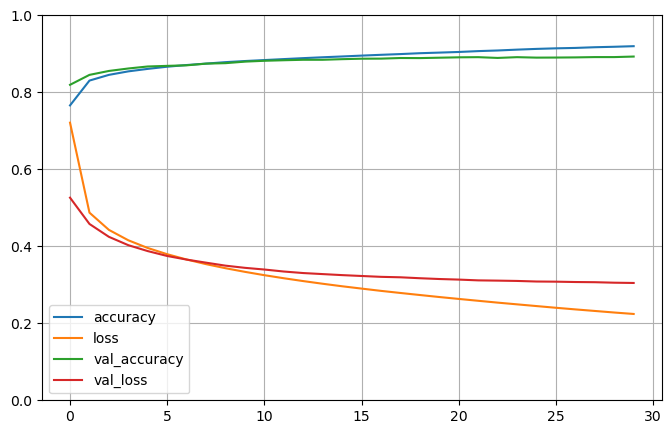

In [27]:
import pandas as pd

pd.DataFrame(model_history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [28]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8791 - loss: 0.3483


[0.3469099998474121, 0.8788999915122986]

In [29]:
X_new = X_test[:3]

In [30]:
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.02, 0.  , 0.02, 0.  , 0.96],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [34]:
y_pred = np.argmax(model.predict(X_new), axis=1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


array([9, 2, 1])

In [35]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

AxesImage(shape=(28, 28))


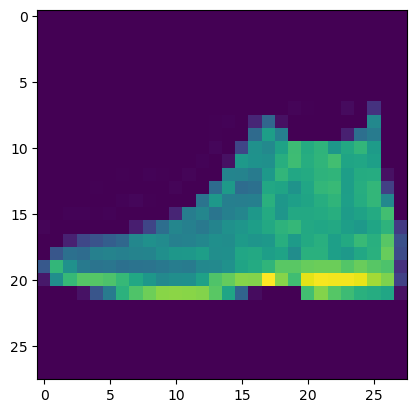

In [36]:
print(plt.imshow(X_test[0]))

AxesImage(shape=(28, 28))


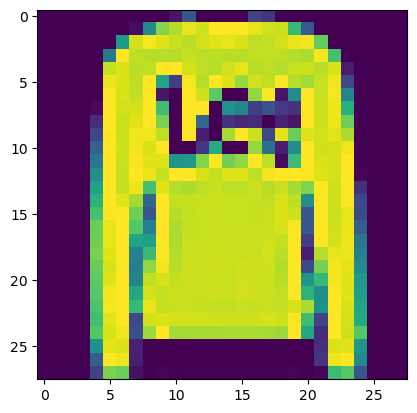

In [37]:
print(plt.imshow(X_test[1]))

AxesImage(shape=(28, 28))


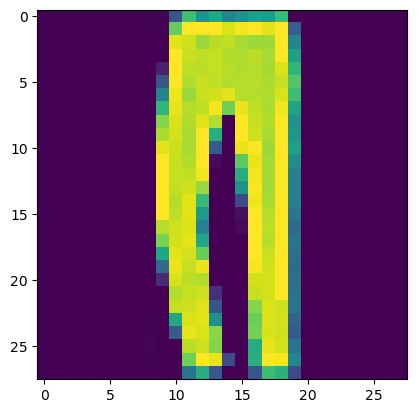

In [38]:
print(plt.imshow(X_test[2]))